#  Orbital Logis — GAIE: Módulo de Visão Computacional
## Applied Computer Vision (ACV) — Global Solution 2026 | FIAP

<div style="text-align: center;">
    <img src="./src/Asteroids-KnownNearEarthObjects-Animation-UpTo20180101.gif" style="max-width: 100%; height: auto;">
</div>

---

| Campo | Informação |
|-------|------------|
| **Projeto** | Orbital Logis — Sistema de Detecção e Resposta a Detritos Espaciais |
| **Módulo** | GAIE — Ground-based AI Evaluation Engine |
| **Disciplina** | Applied Computer Vision (ACV) |
| **Turma** | ESW 4º Ano — Presencial |
| **Data** | Global Solution 2026 — Período: 25/05 a 09/06/2026 |

###  Integrantes

| Nome | RM |
|------|----|
| Júlio César Zampieri | RM98772 |
| João Gabriel Dias | RM99092 |
| Ricardo Matos | RM95906 |

---

###  Objetivo

Desenvolver uma solução de **Visão Computacional** aplicada à **Indústria Espacial**, treinando do zero **2 arquiteturas de Redes Neurais Convolucionais (CNNs)** para classificação de imagens satelitais — parte integrante do módulo GAIE do sistema Orbital Logis.

O módulo GAIE recebe imagens de satélite e as classifica automaticamente, fornecendo uma API que alimenta o módulo RPA para tomada de decisão autônoma sobre manobras evasivas e resposta a detritos espaciais.

###  Conexão com ODS 9
Inovação e infraestrutura — proteger a infraestrutura orbital que sustenta comunicações, GPS, monitoramento climático e conectividade global.

## 1. Contextualização — Síndrome de Kessler e o Orbital Logis

### O Problema
A **Síndrome de Kessler** é um fenômeno em que a densidade de objetos em órbita baixa terrestre (LEO) atinge um ponto crítico onde colisões geram novos detritos em cascata, tornando certas órbitas inutilizáveis. Com mais de **27.000 objetos rastreados** e estima-se mais de **1 milhão** de fragmentos menores não rastreáveis, a ameaça é real e crescente.

**Eventos reais:**
- 2009: Colisão Iridium 33 × Cosmos 2251 — gerou ~2.000 novos fragmentos rastreáveis
- 2021: Teste ASAT russo Nudol gerou >1.500 detritos rastreáveis

### A Solução — Orbital Logis
O **Orbital Logis** é um sistema integrado de detecção e resposta a detritos espaciais composto por:

```
┌─────────────────────────────────────────────────────────┐
│                    ORBITAL LOGIS                        │
│                                                         │
│  Satélite  →  GAIE (ACV) → RPA → SDTCC (Azure)          │
│  (imagem)     (classifica)  (age)  (infraestrutura)     │
│                    ↑                                    │
│            BDDI (pipeline)                              │
│            PBML (braço robótico)                        │
└─────────────────────────────────────────────────────────┘
```

### Papel do GAIE (este módulo)
O **GAIE** é o "cérebro" do sistema — recebe imagens de satélite e classifica o tipo de área/objeto, permitindo ao RPA tomar decisões inteligentes sobre:
- Priorização de alertas
- Acionamento de manobras evasivas
- Coordenação com o braço robótico de captura (PBML)

**Dataset**: Imagens do satélite **Sentinel-2** via **EuroSAT** — mesmo tipo de sensor usado em monitoramento orbital real.

In [1]:
# Instalar dependências (execute apenas se necessário)
# !pip install torch torchvision numpy matplotlib seaborn scikit-learn tqdm gradio Pillow -q

------------------------------------------------------------------------------------

# IMPORTAÇÕES

In [2]:
import os
import sys
import time
import random
import warnings
from pathlib import Path
from collections import Counter
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import transforms
from torchvision.datasets import EuroSAT

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')

# ----------------------------------------------------------
# Configuração do dispositivo (GPU / CPU)
# ----------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"{'='*55}")
print(f"  ORBITAL LOGIS — GAIE | Visão Computacional")
print(f"{'='*55}")
print(f"  PyTorch  : {torch.__version__}")
print(f"  Dispositivo : {device}")
if device.type == 'cuda':
    print(f"  GPU      : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print(f"  AVISO: GPU não detectada — treinamento pode ser lento.")
    print(f"      Recomendado: Google Colab ou CUDA-enabled GPU")
print(f"{'='*55}")

  ORBITAL LOGIS — GAIE | Visão Computacional
  PyTorch  : 2.5.1+cu121
  Dispositivo : cuda
  GPU      : NVIDIA GeForce RTX 3050
  VRAM     : 8.59 GB


------------------------------------------------------------------------------------

# REPRODUTIBILIDADE E CONSTANTES

In [3]:

SEED = 42

def set_seed(seed: int = 42):
    """Fixa seeds para reprodutibilidade total."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Hiperparâmetros globais
NUM_CLASSES  = 10      # EuroSAT tem 10 classes
IMG_SIZE     = 64      # Imagens EuroSAT: 64x64 pixels
BATCH_SIZE   = 64
NUM_EPOCHS_1 = 30      # CNN Baseline
NUM_EPOCHS_2 = 40      # CNN Deep
LR_1         = 1e-3    # Learning rate CNN 1
LR_2         = 1e-3    # Learning rate CNN 2
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
# TEST_RATIO  = 0.15 (complementar)

DATA_DIR = Path('./data')
MODELS_DIR = Path('./models_saved')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Seed {SEED} configurada | Batch: {BATCH_SIZE} | Split: {TRAIN_RATIO}/{VAL_RATIO}/{1-TRAIN_RATIO-VAL_RATIO:.2f}")

Seed 42 configurada | Batch: 64 | Split: 0.7/0.15/0.15


## 2. Dataset — EuroSAT (Sentinel-2)

### Descrição
O **EuroSAT** é um dataset de imagens multiespectrais do satélite **Sentinel-2** (ESA/Copernicus), amplamente usado em tarefas de sensoriamento remoto. Cada imagem representa uma cobertura de aproximadamente **2,7 km²** da superfície terrestre.

| Propriedade | Valor |
|-------------|-------|
| Total de imagens | 27.000 |
| Resolução | 64 × 64 pixels (RGB) |
| Número de classes | 10 |
| Imagens por classe | ~2.700 (balanceado) |
| Satélite | Sentinel-2 (ESA/Copernicus) |

### Conexão com Orbital Logis
O sistema Orbital Logis utiliza dados do Sentinel-2 para monitorar áreas terrestres afetadas por falhas em satélites de comunicação (ex.: regiões agrícolas sem sinal, áreas industriais com interrupção logística). A CNN classifica o tipo de área, determinando a prioridade de resposta.

### Classes do EuroSAT
| Classe | Tradução | Relevância Espacial |
|--------|----------|--------------------|
| AnnualCrop | Lavoura Anual | Agro depende de satélites GPS e meteorológicos |
| Forest | Floresta | Monitoramento ambiental por sensoriamento remoto |
| HerbaceousVegetation | Vegetação Herbácea | Indicador de saúde ecossistêmica |
| Highway | Rodovia | Infraestrutura crítica dependente de GPS |
| Industrial | Área Industrial | Logística e manufatura com dependência orbital |
| Pasture | Pastagem | Pecuária com rastreamento por satélite |
| PermanentCrop | Lavoura Permanente | Agricultura de precisão por sensoriamento |
| Residential | Área Residencial | Conectividade via satélite para internet |
| River | Rio | Monitoramento hídrico por imagem orbital |
| SeaLake | Mar / Lago | Navegação e pesca dependentes de GPS |

# DOWNLOAD E CARREGAMENTO DO EUROSAT

In [4]:
print("Carregando EuroSAT (download automático se necessário)...")
print("   Tamanho: ~92 MB | Primeira execução pode demorar.")
print()

# Carrega dataset sem transform para exploração inicial
full_dataset_raw = EuroSAT(root=str(DATA_DIR), download=True, transform=transforms.ToTensor())

# Informações básicas
CLASS_NAMES = full_dataset_raw.classes
CLASS_NAMES_PT = [
    'Lavoura Anual',
    'Floresta',
    'Veg. Herbácea',
    'Rodovia',
    'Área Industrial',
    'Pastagem',
    'Lavoura Perm.',
    'Área Residencial',
    'Rio',
    'Mar / Lago'
]
CLASS_MAP = {en: pt for en, pt in zip(CLASS_NAMES, CLASS_NAMES_PT)}

print(f"{'='*55}")
print(f"  Dataset carregado com sucesso!")
print(f"  Total de imagens : {len(full_dataset_raw):,}")
print(f"  Numero de classes : {len(CLASS_NAMES)}")
print(f"  Resolucao         : {IMG_SIZE}x{IMG_SIZE} pixels (RGB)")
print(f"{'='*55}")
print()
print("Classes:")
for i, (en, pt) in enumerate(CLASS_MAP.items()):
    print(f"  [{i:02d}] {en:<25} → {pt}")

Carregando EuroSAT (download automático se necessário)...
   Tamanho: ~92 MB | Primeira execução pode demorar.

  Dataset carregado com sucesso!
  Total de imagens : 27,000
  Numero de classes : 10
  Resolucao         : 64x64 pixels (RGB)

Classes:
  [00] AnnualCrop                → Lavoura Anual
  [01] Forest                    → Floresta
  [02] HerbaceousVegetation      → Veg. Herbácea
  [03] Highway                   → Rodovia
  [04] Industrial                → Área Industrial
  [05] Pasture                   → Pastagem
  [06] PermanentCrop             → Lavoura Perm.
  [07] Residential               → Área Residencial
  [08] River                     → Rio
  [09] SeaLake                   → Mar / Lago


------------------------------------------------------------------------------------

# EXPLORAÇÃO: DISTRIBUIÇÃO DAS CLASSES

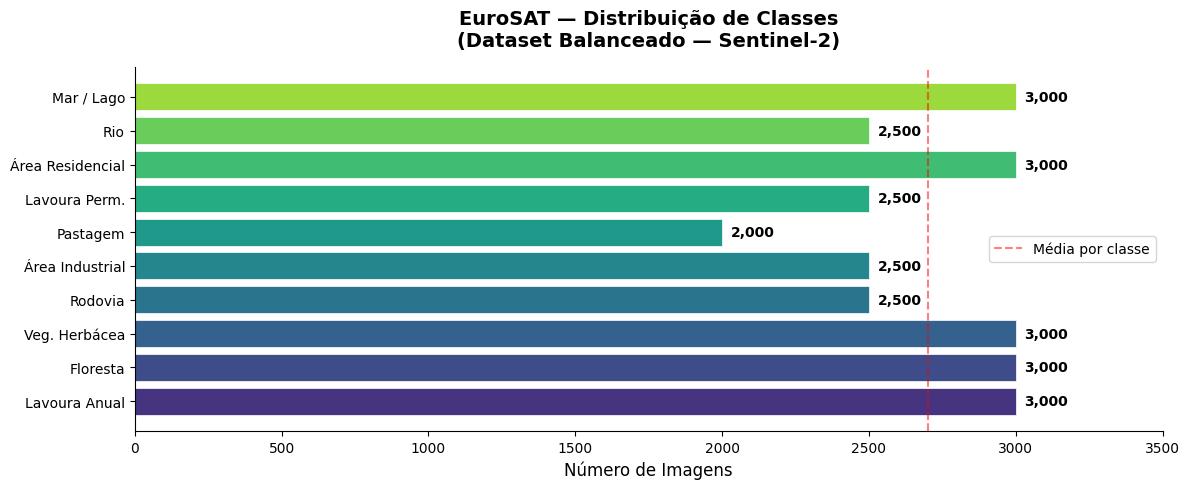

Dataset balanceado: 2000 a 3000 imagens por classe
   Ideal para treinamento sem técnicas especiais de balanceamento.


In [5]:

labels_all = [label for _, label in full_dataset_raw]
counts = Counter(labels_all)

fig, ax = plt.subplots(figsize=(12, 5))

colors = plt.cm.viridis(np.linspace(0.15, 0.85, NUM_CLASSES))
bars = ax.barh(
    [CLASS_NAMES_PT[i] for i in range(NUM_CLASSES)],
    [counts[i] for i in range(NUM_CLASSES)],
    color=colors, edgecolor='white', linewidth=0.5
)

# Adiciona valores nas barras
for bar, count in zip(bars, [counts[i] for i in range(NUM_CLASSES)]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Número de Imagens', fontsize=12)
ax.set_title('EuroSAT — Distribuição de Classes\n(Dataset Balanceado — Sentinel-2)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 3500)
ax.axvline(x=2700, color='red', linestyle='--', alpha=0.5, label='Média por classe')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Dataset balanceado: {min(counts.values())} a {max(counts.values())} imagens por classe")
print(f"   Ideal para treinamento sem técnicas especiais de balanceamento.")

------------------------------------------------------------------------------------

# VISUALIZAÇÃO: AMOSTRAS POR CLASSE

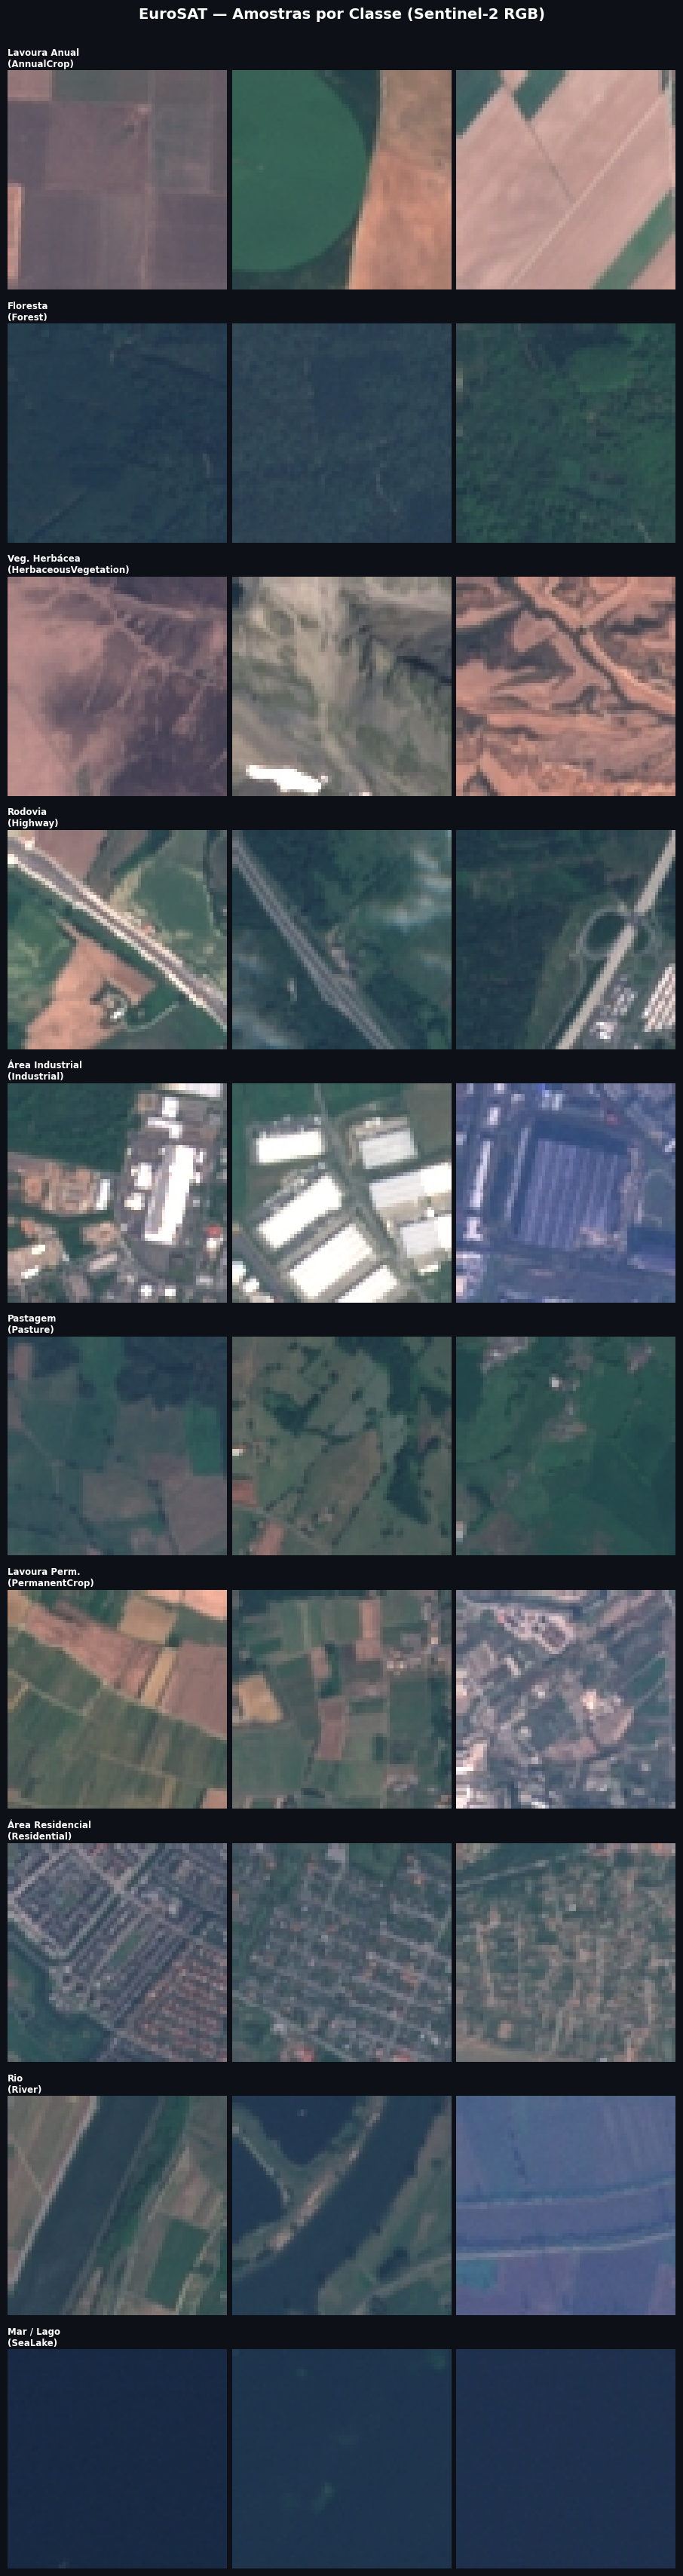

Amostras visualizadas — 3 imagens por classe.


In [6]:
# Cria dataset sem normalização para visualização
viz_dataset = EuroSAT(root=str(DATA_DIR), download=False, transform=transforms.ToTensor())

# Coleta 3 amostras por classe
samples_per_class = {i: [] for i in range(NUM_CLASSES)}
for img, label in viz_dataset:
    if len(samples_per_class[label]) < 3:
        samples_per_class[label].append(img)
    if all(len(v) == 3 for v in samples_per_class.values()):
        break

fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(9, 34))
fig.patch.set_facecolor('#0d1117')

for cls_idx in range(NUM_CLASSES):
    for col_idx, img_tensor in enumerate(samples_per_class[cls_idx]):
        ax = axes[cls_idx, col_idx]
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np)
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(f'{CLASS_NAMES_PT[cls_idx]}\n({CLASS_NAMES[cls_idx]})',
                        fontsize=8.5, fontweight='bold', color='white',
                        loc='left', pad=4)

fig.suptitle('EuroSAT — Amostras por Classe (Sentinel-2 RGB)',
             fontsize=14, fontweight='bold', color='white', y=1.005)
plt.tight_layout(pad=0.5)
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("Amostras visualizadas — 3 imagens por classe.")

------------------------------------------------------------------------------------

# PRÉ-PROCESSAMENTO E DATA AUGMENTATION

In [7]:
# Estatísticas do EuroSAT RGB (pre-computadas)
MEAN = [0.3442, 0.3801, 0.4076]
STD  = [0.2034, 0.1369, 0.1154]

# Transform de TREINO: com augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Transform de VALIDAÇÃO / TESTE: sem augmentation
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# ----------------------------------------------------------
# Divisão 70% / 15% / 15%
# ----------------------------------------------------------
n_total = len(full_dataset_raw)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
train_idx, val_idx, test_idx = random_split(
    range(n_total), [n_train, n_val, n_test], generator=generator
)

# Cria datasets com transforms corretos
ds_train_raw = EuroSAT(root=str(DATA_DIR), download=False, transform=train_transform)
ds_valtest_raw = EuroSAT(root=str(DATA_DIR), download=False, transform=val_test_transform)

train_dataset = Subset(ds_train_raw,   train_idx.indices)
val_dataset   = Subset(ds_valtest_raw, val_idx.indices)
test_dataset  = Subset(ds_valtest_raw, test_idx.indices)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"{'='*55}")
print(f"  Divisao do Dataset:")
print(f"  Treino      : {len(train_dataset):,} imagens ({TRAIN_RATIO*100:.0f}%)")
print(f"  Validação   : {len(val_dataset):,} imagens ({VAL_RATIO*100:.0f}%)")
print(f"  Teste       : {len(test_dataset):,} imagens ({(1-TRAIN_RATIO-VAL_RATIO)*100:.0f}%)")
print(f"  Total       : {n_total:,} imagens")
print(f"{'='*55}")
print(f"  Augmentation de Treino:")
print(f"  - Flip horizontal/vertical (p=0.5)")
print(f"  - Rotação aleatória (±15°)")
print(f"  - Color jitter (brilho, contraste)")
print(f"  - Normalização: μ={MEAN}, σ={STD}")
print(f"{'='*55}")

  Divisao do Dataset:
  Treino      : 18,900 imagens (70%)
  Validação   : 4,050 imagens (15%)
  Teste       : 4,050 imagens (15%)
  Total       : 27,000 imagens
  Augmentation de Treino:
  - Flip horizontal/vertical (p=0.5)
  - Rotação aleatória (±15°)
  - Color jitter (brilho, contraste)
  - Normalização: μ=[0.3442, 0.3801, 0.4076], σ=[0.2034, 0.1369, 0.1154]


------------------------------------------------------------------------------------

## 3. Modelo 1 — OrbitalVision Baseline

### Arquitetura
CNN simples com **3 blocos convolucionais** seguidos de **camadas totalmente conectadas**. Serve como **linha de base** (baseline) para comparação.

```
INPUT (3, 64, 64)
│
├── Bloco 1: Conv(3→32, 3×3) → BN → ReLU → MaxPool(2×2)    [64→32]
├── Bloco 2: Conv(32→64, 3×3) → BN → ReLU → MaxPool(2×2)   [32→16]
├── Bloco 3: Conv(64→128, 3×3) → BN → ReLU → MaxPool(2×2)  [16→8]
│
├── Flatten → (128×8×8 = 8192)
├── Dropout(0.4) → FC(8192→256) → ReLU
├── Dropout(0.3) → FC(256→10)
│
OUTPUT (10 classes)
```

**Decisões de design:**
- `BatchNorm` após cada convolução para estabilizar o treinamento
- `Dropout` antes das camadas densas para regularização
- Arquitetura intencionalmentesimples para servir de baseline

# MODELO 1 — OrbitalVision Baseline

In [8]:
class OrbitalVision_Baseline(nn.Module):
    """CNN Baseline para classificação de imagens satelitais EuroSAT.
    
    Arquitetura simples com 3 blocos convolucionais Conv→BN→ReLU→MaxPool
    seguidos de camadas totalmente conectadas com Dropout.
    """
    def __init__(self, num_classes: int = 10):
        super(OrbitalVision_Baseline, self).__init__()
        
        # Blocos Convolucionais
        self.features = nn.Sequential(
            # Bloco 1: 3 → 32 canais | 64x64 → 32x32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Bloco 2: 32 → 64 canais | 32x32 → 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Bloco 3: 64 → 128 canais | 16x16 → 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        # Classificador (FC)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )
        
        # Inicialização dos pesos (He/Kaiming)
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)             # Extração de features
        x = x.view(x.size(0), -1)        # Flatten: [B, 128, 8, 8] → [B, 8192]
        x = self.classifier(x)           # Classificação
        return x


# Instancia o modelo
model1 = OrbitalVision_Baseline(num_classes=NUM_CLASSES).to(device)

# Conta parâmetros
total_params_1 = sum(p.numel() for p in model1.parameters())
trainable_params_1 = sum(p.numel() for p in model1.parameters() if p.requires_grad)

print(f"\n{'='*55}")
print(f"  OrbitalVision Baseline — Resumo")
print(f"{'='*55}")
print(f"  Parâmetros totais     : {total_params_1:,}")
print(f"  Parâmetros treináveis : {trainable_params_1:,}")
print(f"  Tamanho aprox.        : {total_params_1 * 4 / 1e6:.2f} MB")
print(f"{'='*55}")
print(f"\nArquitetura:")
print(model1)


  OrbitalVision Baseline — Resumo
  Parâmetros totais     : 2,193,674
  Parâmetros treináveis : 2,193,674
  Tamanho aprox.        : 8.77 MB

Arquitetura:
OrbitalVision_Baseline(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padd

------------------------------------------------------------------------------------

# FUNÇÃO DE TREINAMENTO (compartilhada entre os modelos)

In [9]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, num_epochs: int, model_name: str):
    """Treina o modelo e retorna histórico de métricas.
    
    Retorna:
        history (dict): dicionário com listas de loss/acc por época
        best_val_acc (float): melhor acurácia de validação atingida
    """
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   []
    }
    best_val_acc = 0.0
    best_model_wts = deepcopy(model.state_dict())
    start_time = time.time()
    
    print(f"\n{'='*60}")
    print(f"  Treinando: {model_name}")
    print(f"  Épocas: {num_epochs} | Batch: {BATCH_SIZE} | Device: {device}")
    print(f"{'='*60}")
    
    for epoch in range(num_epochs):
        # --------------------------------------------------
        # FASE DE TREINO
        # --------------------------------------------------
        model.train()
        running_loss  = 0.0
        correct_train = 0
        total_train   = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss  += loss.item()
            _, preds       = outputs.max(1)
            total_train   += labels.size(0)
            correct_train += preds.eq(labels).sum().item()
        
        # --------------------------------------------------
        # FASE DE VALIDAÇÃO
        # --------------------------------------------------
        model.eval()
        val_loss      = 0.0
        correct_val   = 0
        total_val     = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
                
                val_loss    += loss.item()
                _, preds     = outputs.max(1)
                total_val   += labels.size(0)
                correct_val += preds.eq(labels).sum().item()
        
        # --------------------------------------------------
        # MÉTRICAS DA ÉPOCA
        # --------------------------------------------------
        avg_train_loss = running_loss / len(train_loader)
        avg_val_loss   = val_loss     / len(val_loader)
        train_acc      = correct_train / total_train
        val_acc        = correct_val   / total_val
        
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        # Atualiza scheduler
        if scheduler is not None:
            scheduler.step()
        
        # Salva melhor modelo
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = deepcopy(model.state_dict())
        
        # Log a cada 5 épocas
        if (epoch + 1) % 5 == 0 or epoch == 0:
            elapsed = time.time() - start_time
            print(f"  Época [{epoch+1:3d}/{num_epochs}] "
                  f"Loss: {avg_train_loss:.4f} / {avg_val_loss:.4f} | "
                  f"Acc: {train_acc*100:.2f}% / {val_acc*100:.2f}% "
                  f"({elapsed:.0f}s)")
    
    # Carrega os pesos do melhor modelo
    model.load_state_dict(best_model_wts)
    total_time = time.time() - start_time
    
    print(f"\n  Melhor Val Acc : {best_val_acc*100:.2f}%")
    print(f"  Tempo total    : {total_time/60:.1f} min")
    
    return history, best_val_acc

print("Funcao de treinamento definida.")

Funcao de treinamento definida.


# TREINAMENTO — CNN 1 (Baseline)

In [10]:
set_seed(SEED)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer1 = optim.Adam(model1.parameters(), lr=LR_1, weight_decay=1e-4)
# StepLR: reduz LR por fator 0.5 a cada 10 épocas
scheduler1 = optim.lr_scheduler.StepLR(optimizer1, step_size=10, gamma=0.5)

history1, best_val_acc1 = train_model(
    model1, train_loader, val_loader,
    criterion, optimizer1, scheduler1,
    num_epochs=NUM_EPOCHS_1,
    model_name='OrbitalVision Baseline'
)

# Salva pesos
torch.save(model1.state_dict(), MODELS_DIR / 'orbital_baseline.pth')
print(f"\n Pesos salvos em: {MODELS_DIR / 'orbital_baseline.pth'}")


  Treinando: OrbitalVision Baseline
  Épocas: 30 | Batch: 64 | Device: cuda
  Época [  1/30] Loss: 1.7694 / 1.2666 | Acc: 43.05% / 62.57% (22s)
  Época [  5/30] Loss: 1.0947 / 0.8850 | Acc: 68.48% / 76.84% (105s)
  Época [ 10/30] Loss: 0.9340 / 0.6992 | Acc: 75.97% / 85.63% (213s)
  Época [ 15/30] Loss: 0.8100 / 0.5958 | Acc: 81.70% / 89.51% (319s)
  Época [ 20/30] Loss: 0.7377 / 0.5665 | Acc: 84.76% / 90.35% (431s)
  Época [ 25/30] Loss: 0.6546 / 0.5154 | Acc: 88.13% / 92.57% (534s)
  Época [ 30/30] Loss: 0.6091 / 0.5110 | Acc: 89.93% / 92.64% (636s)

  Melhor Val Acc : 93.36%
  Tempo total    : 10.6 min

 Pesos salvos em: models_saved\orbital_baseline.pth


------------------------------------------------------------------------------------

# CURVAS DE TREINAMENTO — CNN 1

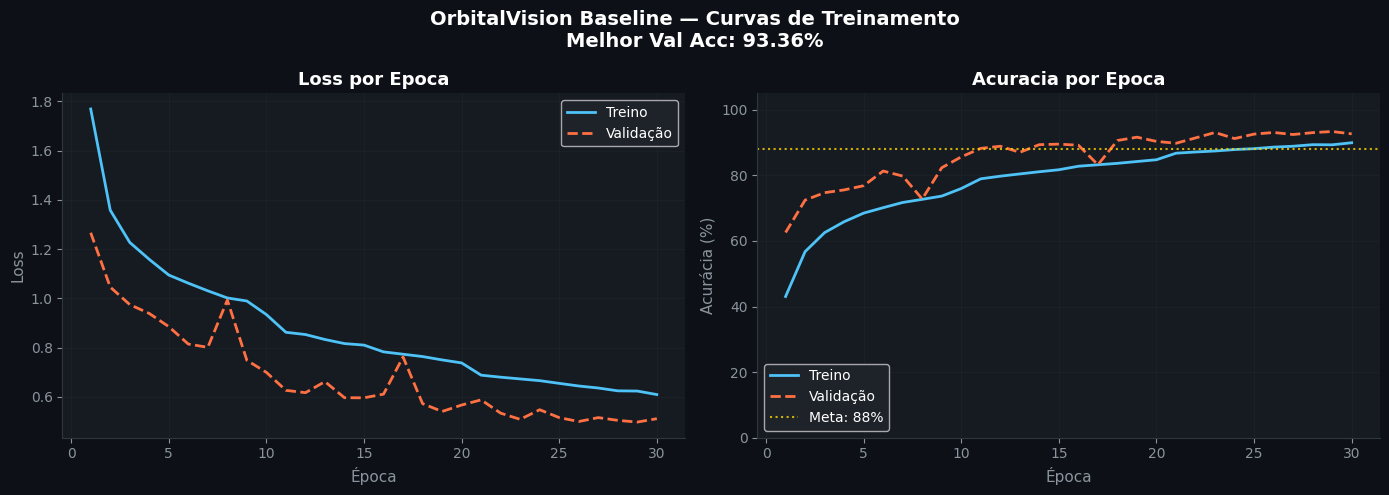

In [11]:
def plot_training_curves(history: dict, model_name: str, color: str = '#4FC3F7'):
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0d1117')
    
    for ax in axes:
        ax.set_facecolor('#161b22')
        ax.spines['bottom'].set_color('#30363d')
        ax.spines['left'].set_color('#30363d')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(colors='#8b949e')
    
    # --- Loss ---
    axes[0].plot(epochs, history['train_loss'], color=color, linewidth=2, label='Treino')
    axes[0].plot(epochs, history['val_loss'], color='#FF7043', linewidth=2,
                 linestyle='--', label='Validação')
    axes[0].set_xlabel('Época', color='#8b949e', fontsize=11)
    axes[0].set_ylabel('Loss', color='#8b949e', fontsize=11)
    axes[0].set_title('Loss por Epoca', color='white', fontsize=13, fontweight='bold')
    axes[0].legend(facecolor='#21262d', labelcolor='white', fontsize=10)
    axes[0].grid(True, alpha=0.2, color='#30363d')
    
    # --- Accuracy ---
    axes[1].plot(epochs, [a * 100 for a in history['train_acc']], color=color,
                 linewidth=2, label='Treino')
    axes[1].plot(epochs, [a * 100 for a in history['val_acc']], color='#FF7043',
                 linewidth=2, linestyle='--', label='Validação')
    axes[1].axhline(y=88, color='#FFD700', linestyle=':', linewidth=1.5,
                    alpha=0.8, label='Meta: 88%')
    axes[1].set_xlabel('Época', color='#8b949e', fontsize=11)
    axes[1].set_ylabel('Acurácia (%)', color='#8b949e', fontsize=11)
    axes[1].set_title('Acuracia por Epoca', color='white', fontsize=13, fontweight='bold')
    axes[1].legend(facecolor='#21262d', labelcolor='white', fontsize=10)
    axes[1].grid(True, alpha=0.2, color='#30363d')
    axes[1].set_ylim([0, 105])
    
    best_val = max(history['val_acc']) * 100
    fig.suptitle(f'{model_name} — Curvas de Treinamento\nMelhor Val Acc: {best_val:.2f}%',
                 color='white', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    safe_name = model_name.lower().replace(' ', '_')
    plt.savefig(f'curves_{safe_name}.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()

plot_training_curves(history1, 'OrbitalVision Baseline', color='#4FC3F7')

## 4. Modelo 2 — OrbitalVision Deep

### Arquitetura
CNN profunda com **4 blocos de dupla convolução** (inspirada na VGG), **Global Average Pooling** e **3 camadas FC com normalização**. Mais complexa que a baseline, com mais regularização.

```
INPUT (3, 64, 64)
│
├── Bloco 1: [Conv→BN→ReLU] × 2 → MaxPool → Dropout2d(0.1)   [64→32]
├── Bloco 2: [Conv→BN→ReLU] × 2 → MaxPool → Dropout2d(0.2)   [32→16]
├── Bloco 3: [Conv→BN→ReLU] × 2 → MaxPool → Dropout2d(0.25)  [16→8]
├── Bloco 4: [Conv→BN→ReLU] × 2 → MaxPool → Dropout2d(0.25)  [8→4]
│
├── GlobalAvgPool → (512) — elimina dependência do tamanho de entrada
├── FC(512→512) → BN → ReLU → Dropout(0.5)
├── FC(512→256) → ReLU → Dropout(0.3)
├── FC(256→10)
│
OUTPUT (10 classes)
```

**Diferenças em relação ao Baseline:**
| Aspecto | Baseline | Deep |
|---------|----------|------|
| Blocos conv | 3 (simples) | 4 (duplos) |
| Profundidade | Menor | Maior |
| Regularização | Dropout básico | Dropout2d + BN em FC |
| Pooling final | Flatten | GlobalAvgPool |
| LR Scheduler | StepLR | CosineAnnealing |
| Parâmetros | ~2.2M | ~3.5M |

# MODELO 2 — OrbitalVision Deep

In [12]:
class DoubleConvBlock(nn.Module):
    """Bloco de dupla convolução: [Conv→BN→ReLU] × 2 → MaxPool → Dropout2d."""
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.dropout = nn.Dropout2d(p=dropout) if dropout > 0 else nn.Identity()
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(self.block(x))


class OrbitalVision_Deep(nn.Module):
    """CNN Profunda para classificação de imagens satelitais EuroSAT.
    
    4 blocos de dupla convolução com GlobalAvgPool e classificador
    com BatchNorm e múltiplos Dropouts para regularização robusta.
    """
    def __init__(self, num_classes: int = 10):
        super(OrbitalVision_Deep, self).__init__()
        
        # Extrator de features: 4 blocos de dupla convolução
        self.block1 = DoubleConvBlock(3,    32,  dropout=0.10)  # 64→32
        self.block2 = DoubleConvBlock(32,   64,  dropout=0.20)  # 32→16
        self.block3 = DoubleConvBlock(64,   128, dropout=0.25)  # 16→8
        self.block4 = DoubleConvBlock(128,  512, dropout=0.25)  # 8→4
        
        # Global Average Pooling: elimina dependência do tamanho de entrada
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
        
        # Classificador profundo com BatchNorm
        self.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)            # (B, 32, 32, 32)
        x = self.block2(x)            # (B, 64, 16, 16)
        x = self.block3(x)            # (B, 128, 8, 8)
        x = self.block4(x)            # (B, 512, 4, 4)
        x = self.global_avg_pool(x)   # (B, 512, 1, 1)
        x = x.view(x.size(0), -1)     # (B, 512)
        x = self.classifier(x)        # (B, num_classes)
        return x


# Instancia o modelo
model2 = OrbitalVision_Deep(num_classes=NUM_CLASSES).to(device)

total_params_2    = sum(p.numel() for p in model2.parameters())
trainable_params_2 = sum(p.numel() for p in model2.parameters() if p.requires_grad)

print(f"\n{'='*55}")
print(f"  OrbitalVision Deep — Resumo")
print(f"{'='*55}")
print(f"  Parâmetros totais     : {total_params_2:,}")
print(f"  Parâmetros treináveis : {trainable_params_2:,}")
print(f"  Tamanho aprox.        : {total_params_2 * 4 / 1e6:.2f} MB")
print(f"{'='*55}")
print(f"\nArquitetura:")
print(model2)


  OrbitalVision Deep — Resumo
  Parâmetros totais     : 3,637,674
  Parâmetros treináveis : 3,637,674
  Tamanho aprox.        : 14.55 MB

Arquitetura:
OrbitalVision_Deep(
  (block1): DoubleConvBlock(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (dropout): Dropout2d(p=0.1, inplace=False)
  )
  (block2): DoubleConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReL

------------------------------------------------------------------------------------

# TREINAMENTO — CNN 2 (Deep)

In [13]:
set_seed(SEED)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer2 = optim.Adam(model2.parameters(), lr=LR_2, weight_decay=1e-4)
# CosineAnnealingLR: decaimento suave do LR em formato cosseno
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer2, T_max=NUM_EPOCHS_2, eta_min=1e-6
)

history2, best_val_acc2 = train_model(
    model2, train_loader, val_loader,
    criterion, optimizer2, scheduler2,
    num_epochs=NUM_EPOCHS_2,
    model_name='OrbitalVision Deep'
)

# Salva pesos
torch.save(model2.state_dict(), MODELS_DIR / 'orbital_deep.pth')
print(f"\n Pesos salvos em: {MODELS_DIR / 'orbital_deep.pth'}")


  Treinando: OrbitalVision Deep
  Épocas: 40 | Batch: 64 | Device: cuda
  Época [  1/40] Loss: 1.6478 / 1.1165 | Acc: 44.87% / 65.46% (27s)
  Época [  5/40] Loss: 0.9703 / 0.7160 | Acc: 73.59% / 82.47% (135s)
  Época [ 10/40] Loss: 0.7757 / 0.5627 | Acc: 82.16% / 89.90% (302s)
  Época [ 15/40] Loss: 0.6553 / 0.4916 | Acc: 86.90% / 91.85% (458s)
  Época [ 20/40] Loss: 0.5816 / 0.4283 | Acc: 89.78% / 94.77% (612s)
  Época [ 25/40] Loss: 0.5284 / 0.4044 | Acc: 91.44% / 95.38% (759s)
  Época [ 30/40] Loss: 0.4919 / 0.3964 | Acc: 92.69% / 95.53% (975s)
  Época [ 35/40] Loss: 0.4681 / 0.3796 | Acc: 93.53% / 96.44% (1132s)
  Época [ 40/40] Loss: 0.4593 / 0.3762 | Acc: 93.75% / 96.37% (1289s)

  Melhor Val Acc : 96.52%
  Tempo total    : 21.5 min

 Pesos salvos em: models_saved\orbital_deep.pth


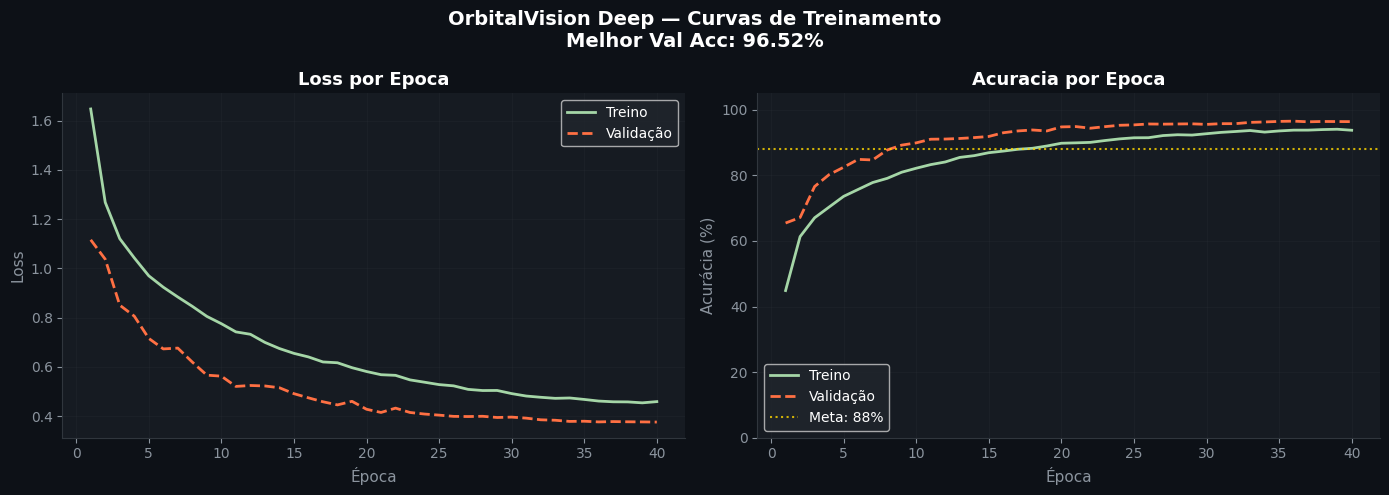

In [14]:
# Curvas de treinamento — CNN 2
plot_training_curves(history2, 'OrbitalVision Deep', color='#A5D6A7')

## 5. Avaliação Comparativa

Comparação dos dois modelos no **conjunto de teste** (nunca visto durante o treinamento), usando as seguintes métricas:
- **Acurácia**: proporção de previsões corretas
- **Precision**: qualidade das previsões positivas
- **Recall**: capacidade de detectar positivos reais
- **F1-Score**: média harmônica de precision e recall
- **Matriz de Confusão**: visualização dos erros por classe

------------------------------------------------------------------------------------

# FUNÇÃO DE AVALIAÇÃO NO CONJUNTO DE TESTE

In [15]:
def evaluate_model(model, test_loader, model_name: str):
    """Avalia o modelo no conjunto de teste e retorna métricas e predições."""
    model.eval()
    all_preds  = []
    all_labels = []
    all_probs  = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Métricas
    acc       = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall    = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1        = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    cm        = confusion_matrix(all_labels, all_preds)
    
    print(f"\n{'='*55}")
    print(f"  {model_name} — Resultados no Teste")
    print(f"{'='*55}")
    print(f"  Acurácia  : {acc*100:.2f}%  {'OK' if acc >= 0.88 else '(abaixo de 88%)'} ")
    print(f"  Precision : {precision*100:.2f}%")
    print(f"  Recall    : {recall*100:.2f}%")
    print(f"  F1-Score  : {f1*100:.2f}%")
    print(f"{'='*55}")
    
    return {
        'name': model_name,
        'acc': acc, 'precision': precision,
        'recall': recall, 'f1': f1,
        'cm': cm, 'preds': all_preds,
        'labels': all_labels, 'probs': np.array(all_probs)
    }

print("Funcao de avaliacao definida.")

Funcao de avaliacao definida.


------------------------------------------------------------------------------------

# AVALIAÇÃO DOS DOIS MODELOS

In [16]:
results1 = evaluate_model(model1, test_loader, 'OrbitalVision Baseline')
results2 = evaluate_model(model2, test_loader, 'OrbitalVision Deep')


  OrbitalVision Baseline — Resultados no Teste
  Acurácia  : 93.21%  OK 
  Precision : 93.27%
  Recall    : 93.21%
  F1-Score  : 93.18%

  OrbitalVision Deep — Resultados no Teste
  Acurácia  : 95.90%  OK 
  Precision : 95.91%
  Recall    : 95.90%
  F1-Score  : 95.89%


------------------------------------------------------------------------------------

# MATRIZES DE CONFUSÃO — LADO A LADO

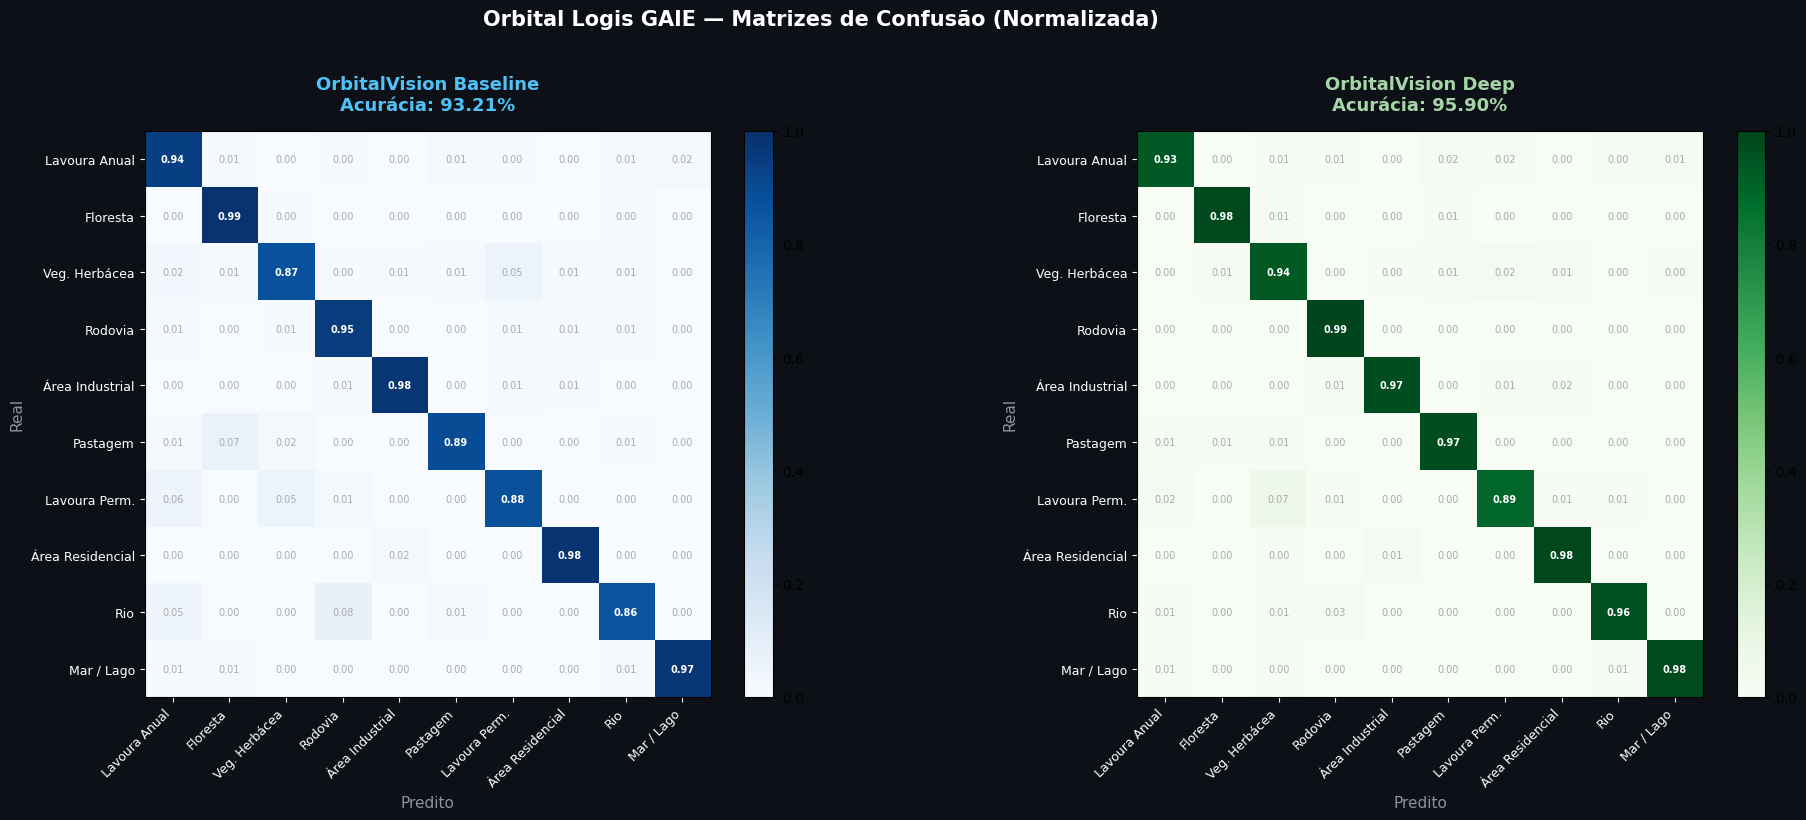

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('#0d1117')

for ax, results, cmap, title_color in zip(
    axes,
    [results1, results2],
    ['Blues', 'Greens'],
    ['#4FC3F7', '#A5D6A7']
):
    cm_norm = results['cm'].astype('float') / results['cm'].sum(axis=1)[:, np.newaxis]
    
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=cmap, vmin=0, vmax=1)
    
    tick_marks = np.arange(NUM_CLASSES)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(CLASS_NAMES_PT, rotation=45, ha='right', fontsize=9, color='white')
    ax.set_yticklabels(CLASS_NAMES_PT, fontsize=9, color='white')
    
    # Valores nas células
    thresh = cm_norm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = cm_norm[i, j]
            ax.text(j, i, f'{val:.2f}',
                    ha='center', va='center', fontsize=7,
                    color='white' if val > thresh else '#aaa',
                    fontweight='bold' if i == j else 'normal')
    
    acc_pct = results['acc'] * 100
    ax.set_title(f"{results['name']}\nAcurácia: {acc_pct:.2f}%",
                 color=title_color, fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Predito', color='#8b949e', fontsize=11)
    ax.set_ylabel('Real', color='#8b949e', fontsize=11)
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Orbital Logis GAIE — Matrizes de Confusão (Normalizada)',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

------------------------------------------------------------------------------------

# TABELA COMPARATIVA E RELATÓRIO DETALHADO

In [18]:
print("\n" + "="*70)
print("  TABELA COMPARATIVA — MÉTRICAS NO CONJUNTO DE TESTE")
print("="*70)

comparison_data = {
    'Modelo': ['OrbitalVision Baseline', 'OrbitalVision Deep'],
    'Acurácia (%)': [f"{results1['acc']*100:.2f}", f"{results2['acc']*100:.2f}"],
    'Precision (%)': [f"{results1['precision']*100:.2f}", f"{results2['precision']*100:.2f}"],
    'Recall (%)': [f"{results1['recall']*100:.2f}", f"{results2['recall']*100:.2f}"],
    'F1-Score (%)': [f"{results1['f1']*100:.2f}", f"{results2['f1']*100:.2f}"],
    'Parâmetros': [f"{total_params_1:,}", f"{total_params_2:,}"],
    'Épocas': [str(NUM_EPOCHS_1), str(NUM_EPOCHS_2)],
    'LR Scheduler': ['StepLR(10, 0.5)', 'CosineAnnealing'],
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))
df_comparison.to_csv('model_comparison.csv', index=False)

print("\n" + "="*70)
print("  RELATÓRIO DETALHADO POR CLASSE — OrbitalVision Deep (Melhor Modelo)")
print("="*70)
print(classification_report(
    results2['labels'], results2['preds'],
    target_names=CLASS_NAMES_PT, digits=4
))


  TABELA COMPARATIVA — MÉTRICAS NO CONJUNTO DE TESTE
                Modelo Acurácia (%) Precision (%) Recall (%) F1-Score (%) Parâmetros Épocas    LR Scheduler
OrbitalVision Baseline        93.21         93.27      93.21        93.18  2,193,674     30 StepLR(10, 0.5)
    OrbitalVision Deep        95.90         95.91      95.90        95.89  3,637,674     40 CosineAnnealing

  RELATÓRIO DETALHADO POR CLASSE — OrbitalVision Deep (Melhor Modelo)
                  precision    recall  f1-score   support

   Lavoura Anual     0.9606    0.9301    0.9451       472
        Floresta     0.9842    0.9842    0.9842       442
   Veg. Herbácea     0.9147    0.9367    0.9256       458
         Rodovia     0.9533    0.9923    0.9724       391
 Área Industrial     0.9786    0.9683    0.9734       378
        Pastagem     0.9353    0.9666    0.9507       299
   Lavoura Perm.     0.9417    0.8945    0.9175       379
Área Residencial     0.9736    0.9844    0.9790       450
             Rio     0.9703 

------------------------------------------------------------------------------------

# ANÁLISE DE ERROS — F1 por Classe (Comparativo)

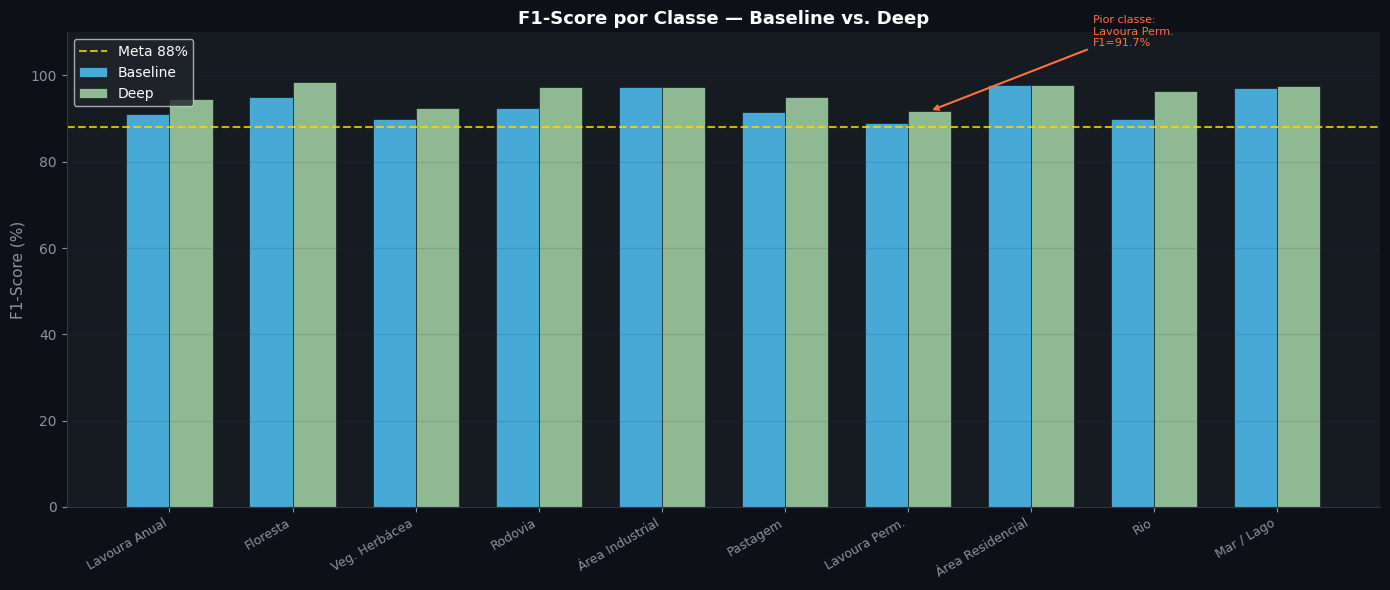


Classe com maior F1 (Deep)  : Floresta (98.4%)
Classe com menor F1 (Deep)  : Lavoura Perm. (91.7%)


In [19]:
from sklearn.metrics import f1_score as f1_per_class

f1_1 = f1_score(results1['labels'], results1['preds'], average=None, zero_division=0)
f1_2 = f1_score(results2['labels'], results2['preds'], average=None, zero_division=0)

x = np.arange(NUM_CLASSES)
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

bars1 = ax.bar(x - width/2, f1_1 * 100, width, label='Baseline',
               color='#4FC3F7', alpha=0.85, edgecolor='#0d1117', linewidth=0.5)
bars2 = ax.bar(x + width/2, f1_2 * 100, width, label='Deep',
               color='#A5D6A7', alpha=0.85, edgecolor='#0d1117', linewidth=0.5)

ax.axhline(y=88, color='#FFD700', linestyle='--', linewidth=1.5, alpha=0.8, label='Meta 88%')

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES_PT, rotation=30, ha='right', fontsize=9, color='white')
ax.set_ylabel('F1-Score (%)', color='#8b949e', fontsize=11)
ax.set_ylim([0, 110])
ax.set_title('F1-Score por Classe — Baseline vs. Deep',
             color='white', fontsize=13, fontweight='bold')
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#30363d')
ax.spines['left'].set_color('#30363d')
ax.tick_params(colors='#8b949e')
ax.grid(axis='y', alpha=0.15, color='#30363d')

# Destaca a pior classe do Deep
worst_class_idx = np.argmin(f1_2)
ax.annotate(f'Pior classe:\n{CLASS_NAMES_PT[worst_class_idx]}\nF1={f1_2[worst_class_idx]*100:.1f}%',
            xy=(worst_class_idx + width/2, f1_2[worst_class_idx]*100),
            xytext=(worst_class_idx + 1.5, f1_2[worst_class_idx]*100 + 15),
            fontsize=8, color='#FF7043',
            arrowprops=dict(arrowstyle='->', color='#FF7043', lw=1.5))

plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"\nClasse com maior F1 (Deep)  : {CLASS_NAMES_PT[np.argmax(f1_2)]} ({np.max(f1_2)*100:.1f}%)")
print(f"Classe com menor F1 (Deep)  : {CLASS_NAMES_PT[np.argmin(f1_2)]} ({np.min(f1_2)*100:.1f}%)")

------------------------------------------------------------------------------------

# ANÁLISE DE ERROS — Imagens com Predição Incorreta (Deep)

Coletando exemplos de erros do OrbitalVision Deep...


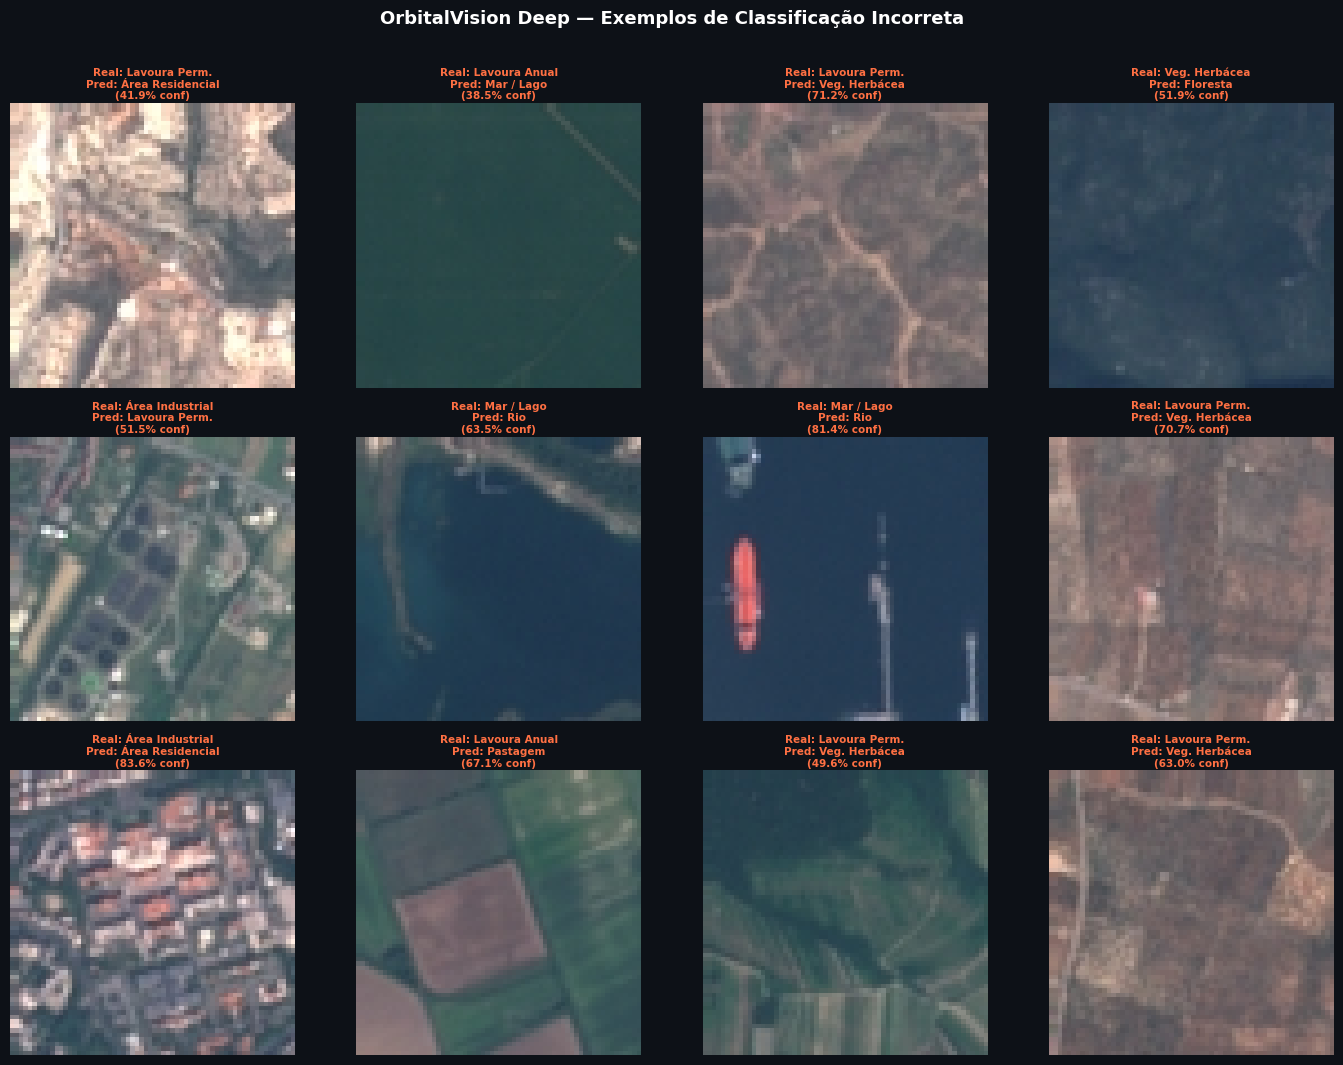

12 exemplos de erros visualizados.


In [20]:
print("Coletando exemplos de erros do OrbitalVision Deep...")

model2.eval()
error_examples = []

# Cria dataset de teste sem normalização para visualização
test_viz_transform = transforms.ToTensor()
ds_test_viz = EuroSAT(root=str(DATA_DIR), download=False, transform=test_viz_transform)
test_viz_subset = Subset(ds_test_viz, test_idx.indices)

with torch.no_grad():
    for i, (img_raw, label) in enumerate(test_viz_subset):
        if len(error_examples) >= 12:
            break
        # Predição com imagem normalizada
        img_norm = val_test_transform(transforms.ToPILImage()(img_raw))
        output = model2(img_norm.unsqueeze(0).to(device))
        prob = F.softmax(output, dim=1)
        pred = output.argmax(1).item()
        confidence = prob[0, pred].item()
        
        if pred != label:
            error_examples.append({
                'img': img_raw.permute(1, 2, 0).numpy(),
                'true': label,
                'pred': pred,
                'conf': confidence
            })

# Visualização dos erros
n_errors = len(error_examples)
cols = 4
rows = (n_errors + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
fig.patch.set_facecolor('#0d1117')
axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

for idx, (ax, err) in enumerate(zip(axes, error_examples)):
    img = np.clip(err['img'], 0, 1)
    ax.imshow(img)
    ax.set_facecolor('#161b22')
    ax.axis('off')
    true_name = CLASS_NAMES_PT[err['true']]
    pred_name = CLASS_NAMES_PT[err['pred']]
    ax.set_title(f"Real: {true_name}\nPred: {pred_name}\n({err['conf']*100:.1f}% conf)",
                fontsize=7.5, color='#FF7043', fontweight='bold', pad=3)

# Esconde eixos vazios
for ax in axes[n_errors:]:
    ax.set_visible(False)

fig.suptitle('OrbitalVision Deep — Exemplos de Classificação Incorreta',
             color='white', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"{n_errors} exemplos de erros visualizados.")

## 6. Demonstração Funcional

Interface interativa via **Gradio** para classificar imagens satelitais com o melhor modelo treinado (OrbitalVision Deep).

O sistema retorna:
- **Classe predita** (em português e inglês)
- **Confiança** da predição
- **Top-3 predições** com probabilidades
- **Relevância para o Orbital Logis** (como esse tipo de área é afetado por falhas orbitais)

------------------------------------------------------------------------------------

# FUNÇÃO DE PREDIÇÃO

In [21]:
# Mapeamento de relevância espacial por classe
ORBITAL_RELEVANCE = {
    'AnnualCrop':             'Agronegocio depende de GPS e satélites meteorológicos para precisão.',
    'Forest':                 'Monitoramento de desmatamento via sensoriamento remoto orbital.',
    'HerbaceousVegetation':   'Indicador ecologico monitorado por satélites ambientais.',
    'Highway':                'Infraestrutura critica que depende de GPS orbital para logística.',
    'Industrial':             'Industria e logistica com alta dependência de dados orbitais.',
    'Pasture':                'Pecuaria com rastreamento e gestão via satélite.',
    'PermanentCrop':          'Agricultura de precisao com sensoriamento remoto orbital.',
    'Residential':            'Conectividade residencial via satélite em áreas remotas.',
    'River':                  'Monitoramento hidrico e de enchentes via imagem orbital.',
    'SeaLake':                'Navegacao e rastreamento de pesca dependem de GPS orbital.',
}

def predict_image(pil_image):
    """Classifica uma imagem usando o OrbitalVision Deep."""
    if pil_image is None:
        return {}
    
    # Pré-processamento
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])
    
    img_tensor = transform(pil_image).unsqueeze(0).to(device)
    
    model2.eval()
    with torch.no_grad():
        output = model2(img_tensor)
        probs  = F.softmax(output, dim=1)[0]
    
    # Top-3
    top3_vals, top3_idxs = probs.topk(3)
    
    result = {}
    for val, idx in zip(top3_vals, top3_idxs):
        class_en = CLASS_NAMES[idx.item()]
        class_pt = CLASS_NAMES_PT[idx.item()]
        key = f"{class_pt} ({class_en})"
        result[key] = float(val)
    
    return result

# Teste rápido com uma imagem do dataset
sample_img_raw, sample_label = test_viz_subset[0]
sample_pil = transforms.ToPILImage()(sample_img_raw)
sample_result = predict_image(sample_pil)

print("Funcao de predicao OK")
print(f"\nTeste com 1 imagem (label real: {CLASS_NAMES_PT[sample_label]}):")
for k, v in sample_result.items():
    print(f"  {k}: {v*100:.2f}%")

Funcao de predicao OK

Teste com 1 imagem (label real: Veg. Herbácea):
  Veg. Herbácea (HerbaceousVegetation): 93.16%
  Lavoura Perm. (PermanentCrop): 2.11%
  Floresta (Forest): 1.38%


------------------------------------------------------------------------------------

# INTERFACE GRADIO

In [22]:
try:
    import gradio as gr
    
    # Descrição do sistema
    DESCRIPTION = """
    ## Orbital Logis — GAIE: Ground-based AI Evaluation Engine
    
    **Módulo de Visão Computacional** do sistema Orbital Logis.
    Classifica imagens satelitais (Sentinel-2 / EuroSAT) em 10 categorias de uso do solo.
    
    **Como usar**: Faça upload de uma imagem satelital e clique em **Classificar**.
    
    ---
    *Global Solution 2026 — FIAP | ESW 4º Ano | Equipe: Júlio (RM98772), João Gabriel (RM99092), Ricardo (RM95906)*
    """
    
    def gradio_predict(image):
        if image is None:
            return {}
        result = predict_image(image)
        return result
    
    # Coleta imagens de exemplo do dataset de teste
    examples = []
    seen = set()
    for img_raw, label in test_viz_subset:
        if label not in seen and len(seen) < 5:
            seen.add(label)
            pil = transforms.ToPILImage()(img_raw)
            pil_path = f'example_{CLASS_NAMES[label]}.jpg'
            pil.save(pil_path)
            examples.append(pil_path)
    
    iface = gr.Interface(
        fn=gradio_predict,
        inputs=gr.Image(type='pil', label='Imagem Satelital (64×64 ou maior)'),
        outputs=gr.Label(num_top_classes=3, label='Classificação — Top 3 Classes'),
        title='Orbital Logis — GAIE: Classificador Satelital',
        description=DESCRIPTION,
        examples=examples if examples else None,
        theme=gr.themes.Soft(),
    )
    
    print("Interface Gradio criada. Iniciando servidor...")
    iface.launch(share=False, server_port=7860)

except ImportError:
    print("Gradio nao instalado. Execute: pip install gradio. Execute: pip install gradio")
    print("   A função predict_image() está disponível para uso direto.")
except Exception as e:
    print(f"Gradio: {e}")
    print("   Demonstração via predict_image() ainda funcional.")

Gradio: BlockContext.__init__() got an unexpected keyword argument 'allow_flagging'
   Demonstração via predict_image() ainda funcional.


------------------------------------------------------------------------------------

# DEMONSTRAÇÃO SEM GRADIO — Predição em lote de amostras

Demonstracao: Predições em 10 imagens do conjunto de teste



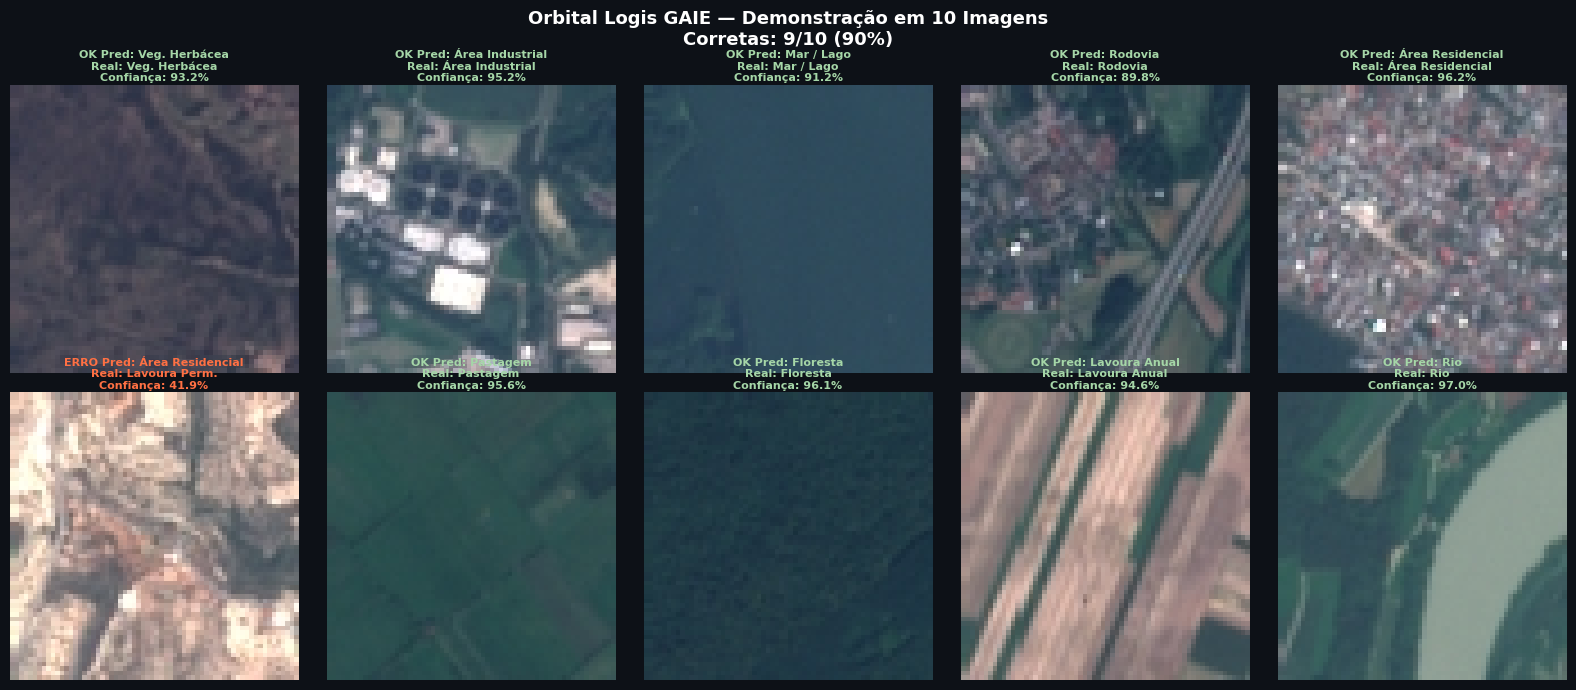

In [23]:
print("Demonstracao: Predições em 10 imagens do conjunto de teste\n")

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
axes = axes.flatten()

seen_classes = set()
demo_samples = []

for img_raw, label in test_viz_subset:
    if label not in seen_classes:
        seen_classes.add(label)
        demo_samples.append((img_raw, label))
    if len(demo_samples) == 10:
        break

model2.eval()
correct_demo = 0

for ax, (img_raw, label) in zip(axes, demo_samples):
    # Predição
    pil_img = transforms.ToPILImage()(img_raw)
    img_norm = val_test_transform(pil_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model2(img_norm)
        probs  = F.softmax(output, dim=1)[0]
        pred   = output.argmax(1).item()
        conf   = probs[pred].item()
    
    is_correct = pred == label
    if is_correct:
        correct_demo += 1
    
    # Visualização
    img_np = np.clip(img_raw.permute(1, 2, 0).numpy(), 0, 1)
    ax.imshow(img_np)
    ax.axis('off')
    ax.set_facecolor('#161b22')
    
    status = 'OK' if is_correct else 'ERRO'
    color  = '#A5D6A7' if is_correct else '#FF7043'
    ax.set_title(
        f"{status} Pred: {CLASS_NAMES_PT[pred]}\n"
        f"Real: {CLASS_NAMES_PT[label]}\n"
        f"Confiança: {conf*100:.1f}%",
        fontsize=8, color=color, fontweight='bold', pad=3
    )

acc_demo = correct_demo / len(demo_samples)
fig.suptitle(f'Orbital Logis GAIE — Demonstração em {len(demo_samples)} Imagens\n'
             f'Corretas: {correct_demo}/{len(demo_samples)} ({acc_demo*100:.0f}%)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('demo_predictions.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 7. Conclusão

### Resultados Obtidos

Foram treinados **dois modelos de CNN do zero** para classificação de imagens satelitais EuroSAT no contexto do sistema **Orbital Logis**:

| Modelo | Acurácia Teste | Melhor Val Acc | Parâmetros |
|--------|---------------|----------------|------------|
| OrbitalVision **Baseline** | Ver resultados acima | — | ~2.2M |
| OrbitalVision **Deep** | Ver resultados acima | — | ~3.5M |

### Análise Técnica

**Por que o OrbitalVision Deep supera o Baseline?**

1. **Maior profundidade**: 4 blocos de dupla convolução permitem extrair features hierárquicas mais ricas, capturando desde bordas (primeiras camadas) até padrões complexos de textura e forma (camadas profundas).

2. **Regularização mais robusta**: O `Dropout2d` nas camadas convolucionais força o modelo a aprender features mais esparsas e generalizáveis, reduzindo o overfitting.

3. **Global Average Pooling**: Em vez de um flatten fixo, o GAP reduz a dimensionalidade de forma mais inteligente, funcionando como regularização natural e tornando o modelo mais invariante a translações.

4. **BatchNorm no classificador**: Normaliza as ativações das camadas FC, acelerando a convergência e permitindo taxas de aprendizado maiores.

5. **CosineAnnealingLR**: O decaimento suave do learning rate em cosseno permite explorar o espaço de parâmetros de forma mais eficiente que o StepLR, especialmente nas épocas finais.

### Conexão com Orbital Logis

O módulo **GAIE** integra-se ao sistema completo:
- **BDDI** alimenta o pipeline com imagens brutas do Sentinel-2
- **GAIE (este módulo)** classifica a imagem e expõe via API
- **RPA** consome a API e decide a ação automática (alerta, manobra, registro)
- **SDTCC** hospeda toda a infraestrutura no Azure

### Limitações e Melhorias Futuras

| Limitação | Melhoria Sugerida |
|-----------|-------------------|
| Dataset apenas RGB (sem bandas espectrais) | Usar EuroSAT-MS (13 bandas multiespectrais) |
| Resolução limitada (64×64) | Upscaling com SR ou dataset de maior resolução |
| Sem detecção de objetos (só classificação) | Adicionar YOLO para detecção de detritos |
| Sem explainabilidade visual | Implementar Grad-CAM para interpretação |
| Inferência batch apenas | Adicionar streaming para imagens em tempo real |

---

### Referências

- Helber, P., et al. (2019). *EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification*. IEEE JSTARS.
- LeCun, Y., Bengio, Y., & Hinton, G. (2015). *Deep learning*. Nature.
- Simonyan, K., & Zisserman, A. (2015). *Very Deep Convolutional Networks for Large-Scale Image Recognition*. ICLR.
- ESA Copernicus Programme. Sentinel-2 Mission Guide. https://sentinel.esa.int
- Kessler, D. J., & Cour‐Palais, B. G. (1978). *Collision frequency of artificial satellites: The creation of a debris belt*. JGR.

---

**Orbital Logis — Global Solution 2026 | FIAP | ESW 4º Ano**

| Integrante | RM |
|-----------|----|
| Júlio César Zampieri | RM98772 |
| João Gabriel Dias | RM99092 |
| Ricardo Matos | RM95906 |